In [1]:
import os
import sys

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile

from utils.architecture import Unet
from utils.diffusion import ElucidatedDiffusion

torch.manual_seed(23)
import pickle

DTYPE = torch.float32

scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import scipy.stats as stats
from sklearn.decomposition import TruncatedSVD

Using device: cuda


In [2]:
def error_metric(pred,true, Par):
    #re-normalize
    # true = true*Par['out_scale'] + Par['out_shift']
    # true = true*Par['out_scale'] + Par['out_shift']
    return torch.norm(true-pred, p=2)/torch.norm(true, p=2)

class MyDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x_sample = self.x[idx]
        y_sample = self.y[idx]

        if self.transform:
            x_sample, y_sample = self.transform(x_sample, y_sample)

        return x_sample, y_sample
    
def preprocess(x,y, Par):
    # x = sliding_window_view(x[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])
    # y = sliding_window_view(y[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])

    print('x: ', x.shape)
    print('y: ', y.shape)
    print()
    return x,y


In [3]:
res = 128
begin_time = time.time()
# inp = np.load(f"/oscar/data/gk/voommen/no_diffusion/kolmogrov/res_{res}/matcho/Y_PRED.npy") #low-fidelity
# out = np.load(f"/oscar/data/gk/voommen/no_diffusion/kolmogrov/res_{res}/matcho/Y_TRUE.npy") #high-fidelity
x_train = np.load("../TRAIN_PRED.npy")
y_train = np.load("../TRAIN_TRUE.npy")

x_val = np.load("../VAL_PRED.npy")
y_val = np.load("../VAL_TRUE.npy")

x_test = np.load("../TEST_PRED.npy")
y_test = np.load("../TEST_TRUE.npy")
print(f"Data Loading Time: {time.time() - begin_time:.1f}s")



# # Train-Val-Test Split
# idx1 = int(0.8 * inp.shape[0])
# idx2 = int(0.9 * inp.shape[0])

# x_train = inp[:idx1]
# x_val   = inp[idx1:idx2]
# x_test  = inp[idx2:]

# y_train = out[:idx1]
# y_val   = out[idx1:idx2]
# y_test  = out[idx2:]



inp_min = np.min(x_train)
inp_max = np.max(x_train)
out_min = np.min(y_train)
out_max = np.max(y_train)



Par = {"inp_shift" : torch.tensor(inp_min, dtype=DTYPE, device=device),
       "inp_scale" : torch.tensor(inp_max - inp_min, dtype=DTYPE, device=device),
       "out_shift" : torch.tensor(out_min, dtype=DTYPE, device=device),
       "out_scale" : torch.tensor(out_max - out_min, dtype=DTYPE, device=device),
       "nx"        : x_train.shape[2],
       "ny"        : x_train.shape[3],
       "nf"        : 1,
       "lb"        : 1,
       "lf"        : 1,
       "num_epochs": 1000
       }

# Normalizing the data to [0,1]
shift = Par['inp_shift'].detach().cpu().numpy()
scale = Par['inp_scale'].detach().cpu().numpy()
x_train = (x_train - shift)/scale
x_val = (x_val - shift)/scale
x_test = (x_test - shift)/scale

shift = Par['out_shift'].detach().cpu().numpy()
scale = Par['out_scale'].detach().cpu().numpy()
y_train = (y_train - shift)/scale
y_val = (y_val - shift)/scale
y_test = (y_test - shift)/scale

Par["sigma_data"] = np.std(y_train)

# Traj splitting
begin_time = time.time()
print('\nTrain Dataset')
x_train, y_train = preprocess(x_train, y_train, Par)
print('\nValidation Dataset')
x_val, y_val = preprocess(x_val, y_val, Par)
print('\nTest Dataset')
x_test, y_test = preprocess(x_test, y_test, Par)
print(f"Data Preprocess Time: {time.time() - begin_time:.1f}s")

Par.update({"channels"       : x_train.shape[1],
            "self_condition" : True
            })

print("Par")
with open('Par.pkl', 'wb') as f:
    pickle.dump(Par, f)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_val_tensor   = torch.tensor(x_val,   dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)

x_test_tensor  = torch.tensor(x_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

train_dataset = MyDataset(x_train_tensor, y_train_tensor)
val_dataset = MyDataset(x_val_tensor, y_val_tensor)
test_dataset = MyDataset(x_test_tensor, y_test_tensor)

# Define data loaders
train_batch_size = 10 #100 #16
val_batch_size   = 10 #100
test_batch_size  = 10 #100
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_batch_size)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size)

Data Loading Time: 0.6s

Train Dataset
x:  (790, 10, 128, 256)
y:  (790, 10, 128, 256)


Validation Dataset
x:  (90, 10, 128, 256)
y:  (90, 10, 128, 256)


Test Dataset
x:  (90, 10, 128, 256)
y:  (90, 10, 128, 256)

Data Preprocess Time: 0.0s
Par


In [4]:
# Define Network Architecture
net = Unet(
    dim = 16,
    dim_mults = (1, 2, 4, 8),
    channels = Par["channels"],
    self_condition = Par["self_condition"],
    flash_attn = True
).to(device).to(torch.float32)
summary(net, input_size=((1,)+x_train.shape[1:], (1,)) )

model = ElucidatedDiffusion(net,
                                channels = Par["channels"],
                                image_size_h=Par["nx"],
                                image_size_w=Par["ny"],
                                sigma_data=Par["sigma_data"])

path_model = 'models/best_model.pt'
# path_model = 'models/model_2000.pt'
model.load_state_dict(torch.load(path_model))

Non-A100 GPU detected, using math or mem efficient attention if input tensor is on cuda


<All keys matched successfully>

In [5]:
l_fidel_ls = []
y_pred_ls = []
y_true_ls = []

model.eval()
test_loss = 0.0
with torch.no_grad():
    for l_fidel, h_fidel in test_loader:
        with autocast():
            pred = model.sample(l_fidel.to(device), num_sample_steps=32)
            loss   = error_metric(pred, h_fidel.to(device), Par)
        test_loss += loss.item()
        l_fidel_ls.append(l_fidel)
        y_true_ls.append(h_fidel)
        y_pred_ls.append(pred)

test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4e}')

sampling time step: 100%|██████████| 32/32 [00:00<00:00, 37.61it/s]

Test Loss: 1.2391e-01


In [6]:
y_true = torch.cat(y_true_ls, dim=0).detach().cpu().numpy().reshape(-1, 10, Par["nx"], Par["ny"])
y_pred = torch.cat(y_pred_ls, dim=0).detach().cpu().numpy().reshape(-1, 10, Par["nx"], Par["ny"])
y_no   = torch.cat(l_fidel_ls, dim=0).detach().cpu().numpy().reshape(-1,10, Par["nx"], Par["ny"])

# Renormalize from [0,1] to actual distribution
y_true = y_true * Par['out_scale'].detach().cpu().numpy() + Par['out_shift'].detach().cpu().numpy()
y_pred = y_pred * Par['out_scale'].detach().cpu().numpy() + Par['out_shift'].detach().cpu().numpy()
y_no   = y_no   * Par['inp_scale'].detach().cpu().numpy() + Par['inp_shift'].detach().cpu().numpy()

print(f"y_true: {y_true.shape}")
print(f"y_pred: {y_pred.shape}")
print(f"y_no  : {y_no.shape}")

y_true: (90, 10, 128, 256)
y_pred: (90, 10, 128, 256)
y_no  : (90, 10, 128, 256)


In [8]:
t_ls = np.linspace(0,25,51)[4:]
t_ls

array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
        7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
       13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. , 17.5, 18. ,
       18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5, 22. , 22.5, 23. , 23.5,
       24. , 24.5, 25. ])

k_x_nq: 2872.313283282097
k_y_nq: 2872.313283282097
k_nq: 2872.313283282097

p: 0
(2, 128, 256)
[4 8]


/tmp/ipykernel_237705/1693504597.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


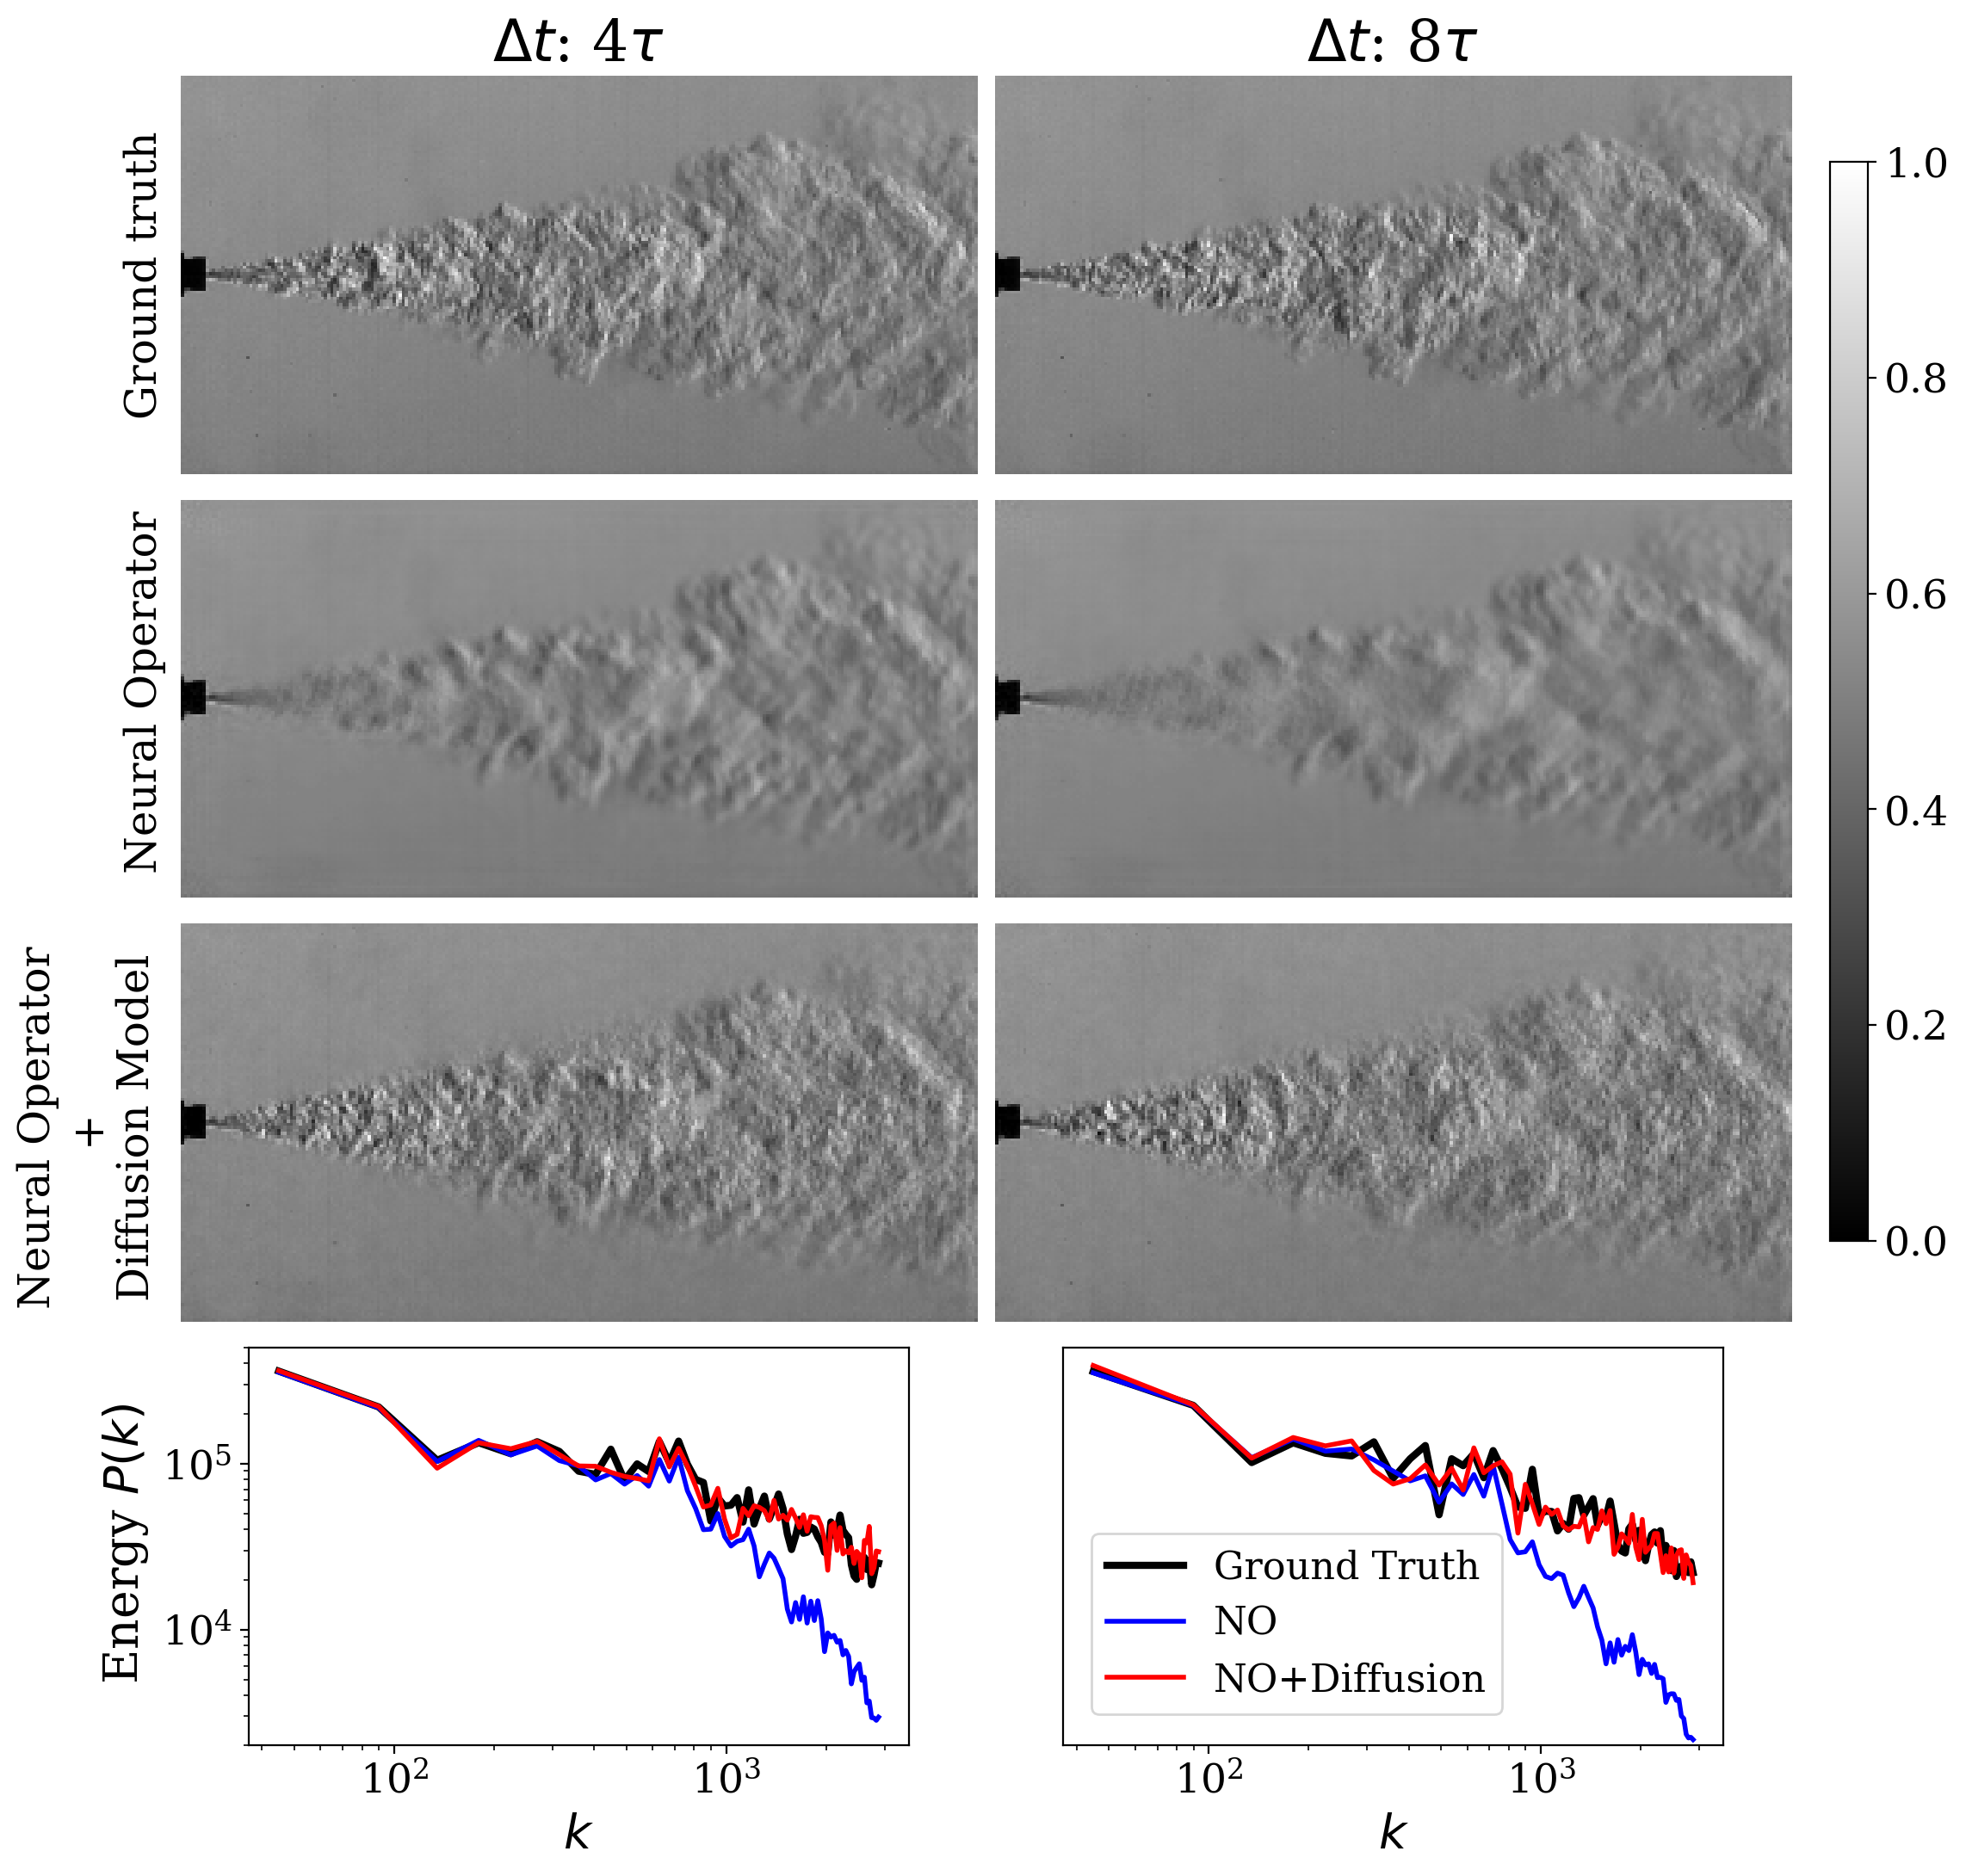

In [10]:
d = 1.4 * 10**-3
Ny = 128
Nx = 256

Lx = 200 * d
Ly = 100 * d

delta_x = Lx/Nx
delta_y = Ly/Ny

k_x_nq = np.pi/delta_x
k_y_nq = np.pi/delta_y
k_nq   = min(k_x_nq, k_y_nq)

print(f"k_x_nq: {k_x_nq}")
print(f"k_y_nq: {k_y_nq}")
print(f"k_nq: {k_y_nq}")

for p in [0]:
    print()
    print(f"p: {p}")
    sample_id = p
    skip_t = 5
    t_ls = ((np.arange(11)[1:]))
    t_idx = [3,7]
    true = y_true[sample_id][t_idx]
    pred1 = y_no[sample_id][t_idx]
    pred2 = y_pred[sample_id][t_idx]
    time_ls = t_ls[t_idx]

    
    
    print(true.shape)
    print(time_ls)
    
    CMAP = 'gray' #'inferno' #'gist_heat'
    
    # Function to calculate MSE
    def mse(a, b):
        return np.mean((a - b) ** 2)
    
    def rel_l2(T, P):
        T = torch.tensor(T, dtype=DTYPE)
        P = torch.tensor(P, dtype=DTYPE)
        return torch.norm(T-P, p=2)/torch.norm(T, p=2).cpu().numpy()
    
    # Create the figure and axis
    # fig, axes = plt.subplots(4, 3, figsize=(30, 11))
    # cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])  # Colorbar axis

    fig, axes = plt.subplots(4, len(time_ls), figsize=(11, 11), gridspec_kw={'height_ratios': [1, 1, 1, 1]})
    cbar_ax = fig.add_axes([0.9, 0.34, 0.02, 0.57])  # Adjust colorbar positioning [left, bottom, width, height]
    # cbar.ax.tick_params(labelsize=17)

    
    # Find the min and max values for colorbar
    vmin = 0#min(true.min(), pred1.min(), pred2.min())
    vmax = 1#max(true.max(), pred1.max(), pred2.max())

    true_temp  = np.copy(true)
    pred1_temp = np.copy(pred1)
    pred2_temp = np.copy(pred2)
    
    # true_temp[airfoil_mask == 0]  = np.nan
    # pred1_temp[airfoil_mask == 0] = np.nan
    # pred2_temp[airfoil_mask == 0] = np.nan
    
    # Plot the images
    for i in range(2):

        # Ground truth row
        im = axes[0, i].imshow(np.fliplr(true_temp[i]), origin='lower', vmin=vmin, vmax=vmax, cmap=CMAP)
        axes[0, i].set_title(r'$\Delta t$: '+f'{time_ls[i]}'+r'$\tau$', fontsize=24)
        axes[0, i].axis('off')
    
        # Prediction 1 row
        im = axes[1, i].imshow(np.fliplr(pred1_temp[i]), origin='lower', vmin=vmin, vmax=vmax, cmap=CMAP)
        # err = rel_l2(true[i], pred1[i])
        # axes[1, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
        axes[1, i].axis('off')
    
        # Prediction 2 row
        im = axes[2, i].imshow(np.fliplr(pred2_temp[i]), origin='lower', vmin=vmin, vmax=vmax, cmap=CMAP)
        # err = rel_l2(true[i], pred2[i])
        # axes[2, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
        axes[2, i].axis('off')
    
    
    
        #######################
    
        image = true[i]    
        ny, nx = image.shape
    
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq_y = np.fft.fftfreq(ny) * ny
        kfreq_x = np.fft.fftfreq(nx) * nx
        kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
        knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        kvals = kvals / (0.5*min(nx, ny)) * k_nq
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
        
        # Plotting    
        axes[3, i].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)
    
    
        
        image = pred1[i]    
        ny, nx = image.shape
    
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq_y = np.fft.fftfreq(ny) * ny
        kfreq_x = np.fft.fftfreq(nx) * nx
        kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
        knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        kvals = kvals / (0.5*min(nx, ny)) * k_nq
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
        
        
        # Plotting    
        axes[3, i].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)
    
    
    
    
        image = pred2[i]    
        ny, nx = image.shape
    
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq_y = np.fft.fftfreq(ny) * ny
        kfreq_x = np.fft.fftfreq(nx) * nx
        kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
        knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        kvals = kvals / (0.5*min(nx, ny)) * k_nq
            
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
        
        
        # Plotting    
        axes[3, i].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)

        axes[3, i].set_ylim(2*10**3,5*10**5)

        for ax in axes[3, :]:  # Adjusting only the last row axes
            ax.tick_params(axis='both', which='major', labelsize=17)
        
        if i!=0:
            axes[3,i].get_yaxis().set_visible(False)
    
    
        
    
        # Adding the -5/3 slope line
        k_ref = np.linspace(1, np.max(kbins), 100)  # Range of wavenumber for the reference line
        energy_ref = k_ref**(-5/3)  # Energy corresponding to the -5/3 slope
        energy_ref *= max(Abins) / max(energy_ref)  # Normalize to plot scale    
    
        axes[3, i].set_xlabel('$k$', fontsize=20)
        if i == 1:
            # axes[3, i].loglog(k_ref, 5*energy_ref, 'k--', label='k^-5/3 Reference', linewidth=2)
            leg = axes[3, i].legend()
            # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
            handles, labels = axes[3, i].get_legend_handles_labels()

            # Remove the original legend from the axes
            leg.remove()
            
            # Define custom coordinates for the new legend (adjust these values to your liking)
            custom_x = 0.5  # Adjust this value to move left-right
            custom_y = 0.08  # Adjust this value to move up-down
            
            # Create a new standalone legend at the custom coordinates on the figure
            fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=16)


        # axes[3,i].set_aspect(1/3)
        axes[3,i].set_aspect(0.5)
    
        ################## 
    
        
    
    
    
    
    
    # Add row labels
    # Add row labels
    fig.text(0.01, 0.85, 'Ground truth', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(0.01, 0.63, 'Neural Operator', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(-0.02, 0.4, 'Neural Operator\n+\nDiffusion Model', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(0.0, 0.18, r'Energy $P(k)$', va='center', ha='center', rotation='vertical', fontsize=20)
    
    # Adjust layout
    fig.tight_layout(rect=[0, 0, 0.9, 1])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=17)
    plt.show()

# Energy Spectrum

In [11]:
def do_svd(data):
    TRAJ = data.reshape(data.shape[0], -1)
    ld = TRAJ.shape[0] #train_ld.shape[-1]
    n_components = ld-1
    
    t_svd = TruncatedSVD(n_components=n_components)
    
    us_train = t_svd.fit_transform(TRAJ)
    s_train  = t_svd.singular_values_
    v_train  = t_svd.components_
    
    error = np.abs(TRAJ - np.matmul(us_train, v_train))
    
    print('us_train: ', us_train.shape)
    print('s_train : ', s_train.shape)
    print('v_train : ', v_train.shape)
    
    print('train error')
    print('min and max error : ', np.min(error), np.max(error))
    print('mean and std error: ', np.mean(error), np.std(error))
    
    return s_train, v_train

In [11]:
t_idx = 1
sample_id = 10
print("TRUE")
s_true, v_true = do_svd(y_true[sample_id])
print("\nNO")
s_no, v_no = do_svd(y_no[sample_id])
print("\nPRED")
s_pred, v_pred = do_svd(y_pred[sample_id])

TRUE
us_train:  (10, 9)
s_train :  (9,)
v_train :  (9, 32768)
train error
min and max error :  0.0 0.15787989
mean and std error:  0.002557652 0.00595025

NO
us_train:  (10, 9)
s_train :  (9,)
v_train :  (9, 32768)
train error
min and max error :  0.0 0.0014909506
mean and std error:  4.3535354e-05 8.531809e-05

PRED
us_train:  (10, 9)
s_train :  (9,)
v_train :  (9, 32768)
train error
min and max error :  0.0 0.24833497
mean and std error:  0.0035654572 0.008813764


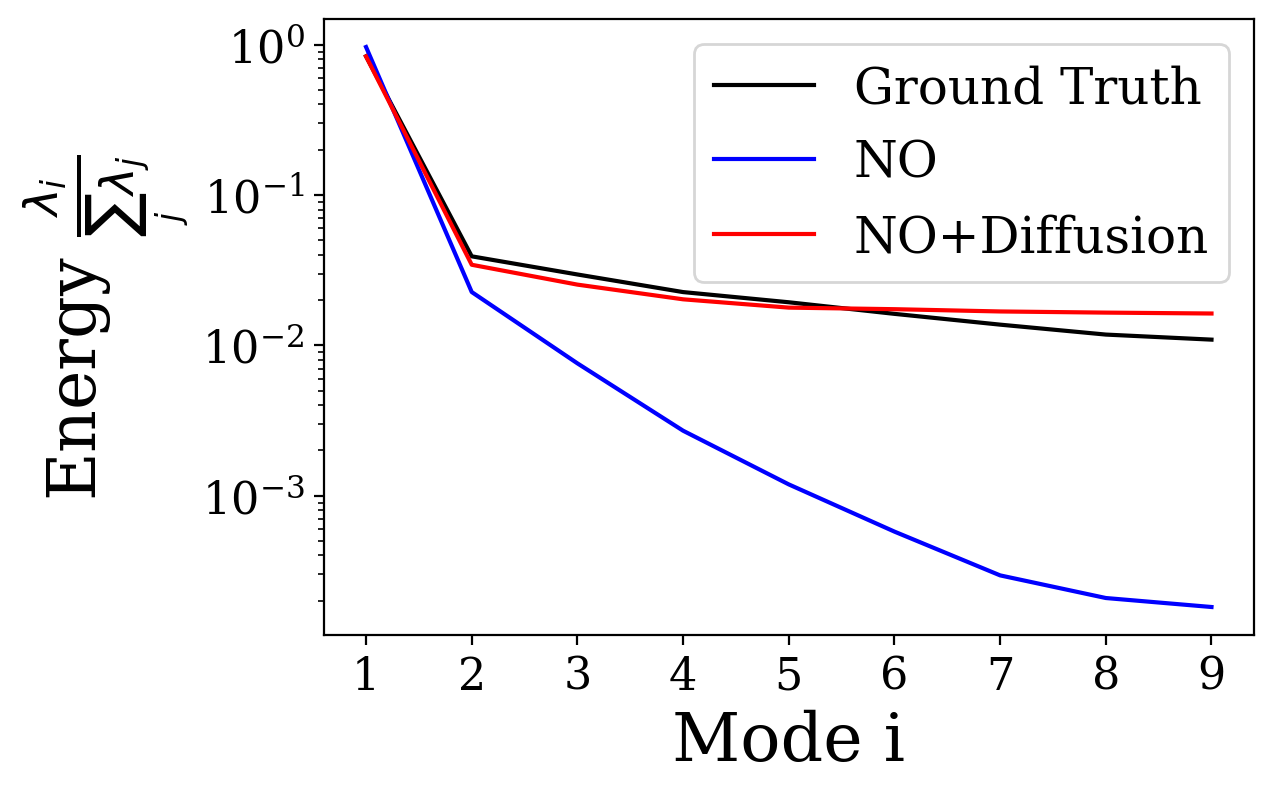

In [12]:
fig = plt.figure(figsize=(6,4))

# plt.scatter(range(1,len(s_train)+1), s_train/np.sum(s_train), s=20, facecolors='none', edgecolors='red')
plt.plot(range(1,len(s_true)+1), s_true/np.sum(s_true), c='black', label='Ground Truth')
plt.plot(range(1,len(s_no)+1), s_no/np.sum(s_no), c='blue', label='NO')
plt.plot(range(1,len(s_pred)+1), s_pred/np.sum(s_pred), c='red', label='NO+Diffusion')


plt.ylabel('Energy '+r'$\frac{\lambda_i}{\sum_j \lambda_j}$', fontsize=24)
plt.xlabel('Mode i', fontsize=24)
plt.legend(fontsize=18)
# plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [13]:
mode_idx = [0,2,4,6,8]
V_TRUE = v_true.reshape(-1, 128,256)[mode_idx]
V_NO = v_no.reshape(-1, 128,256)[mode_idx]
V_PRED = v_pred.reshape(-1, 128,256)[mode_idx]

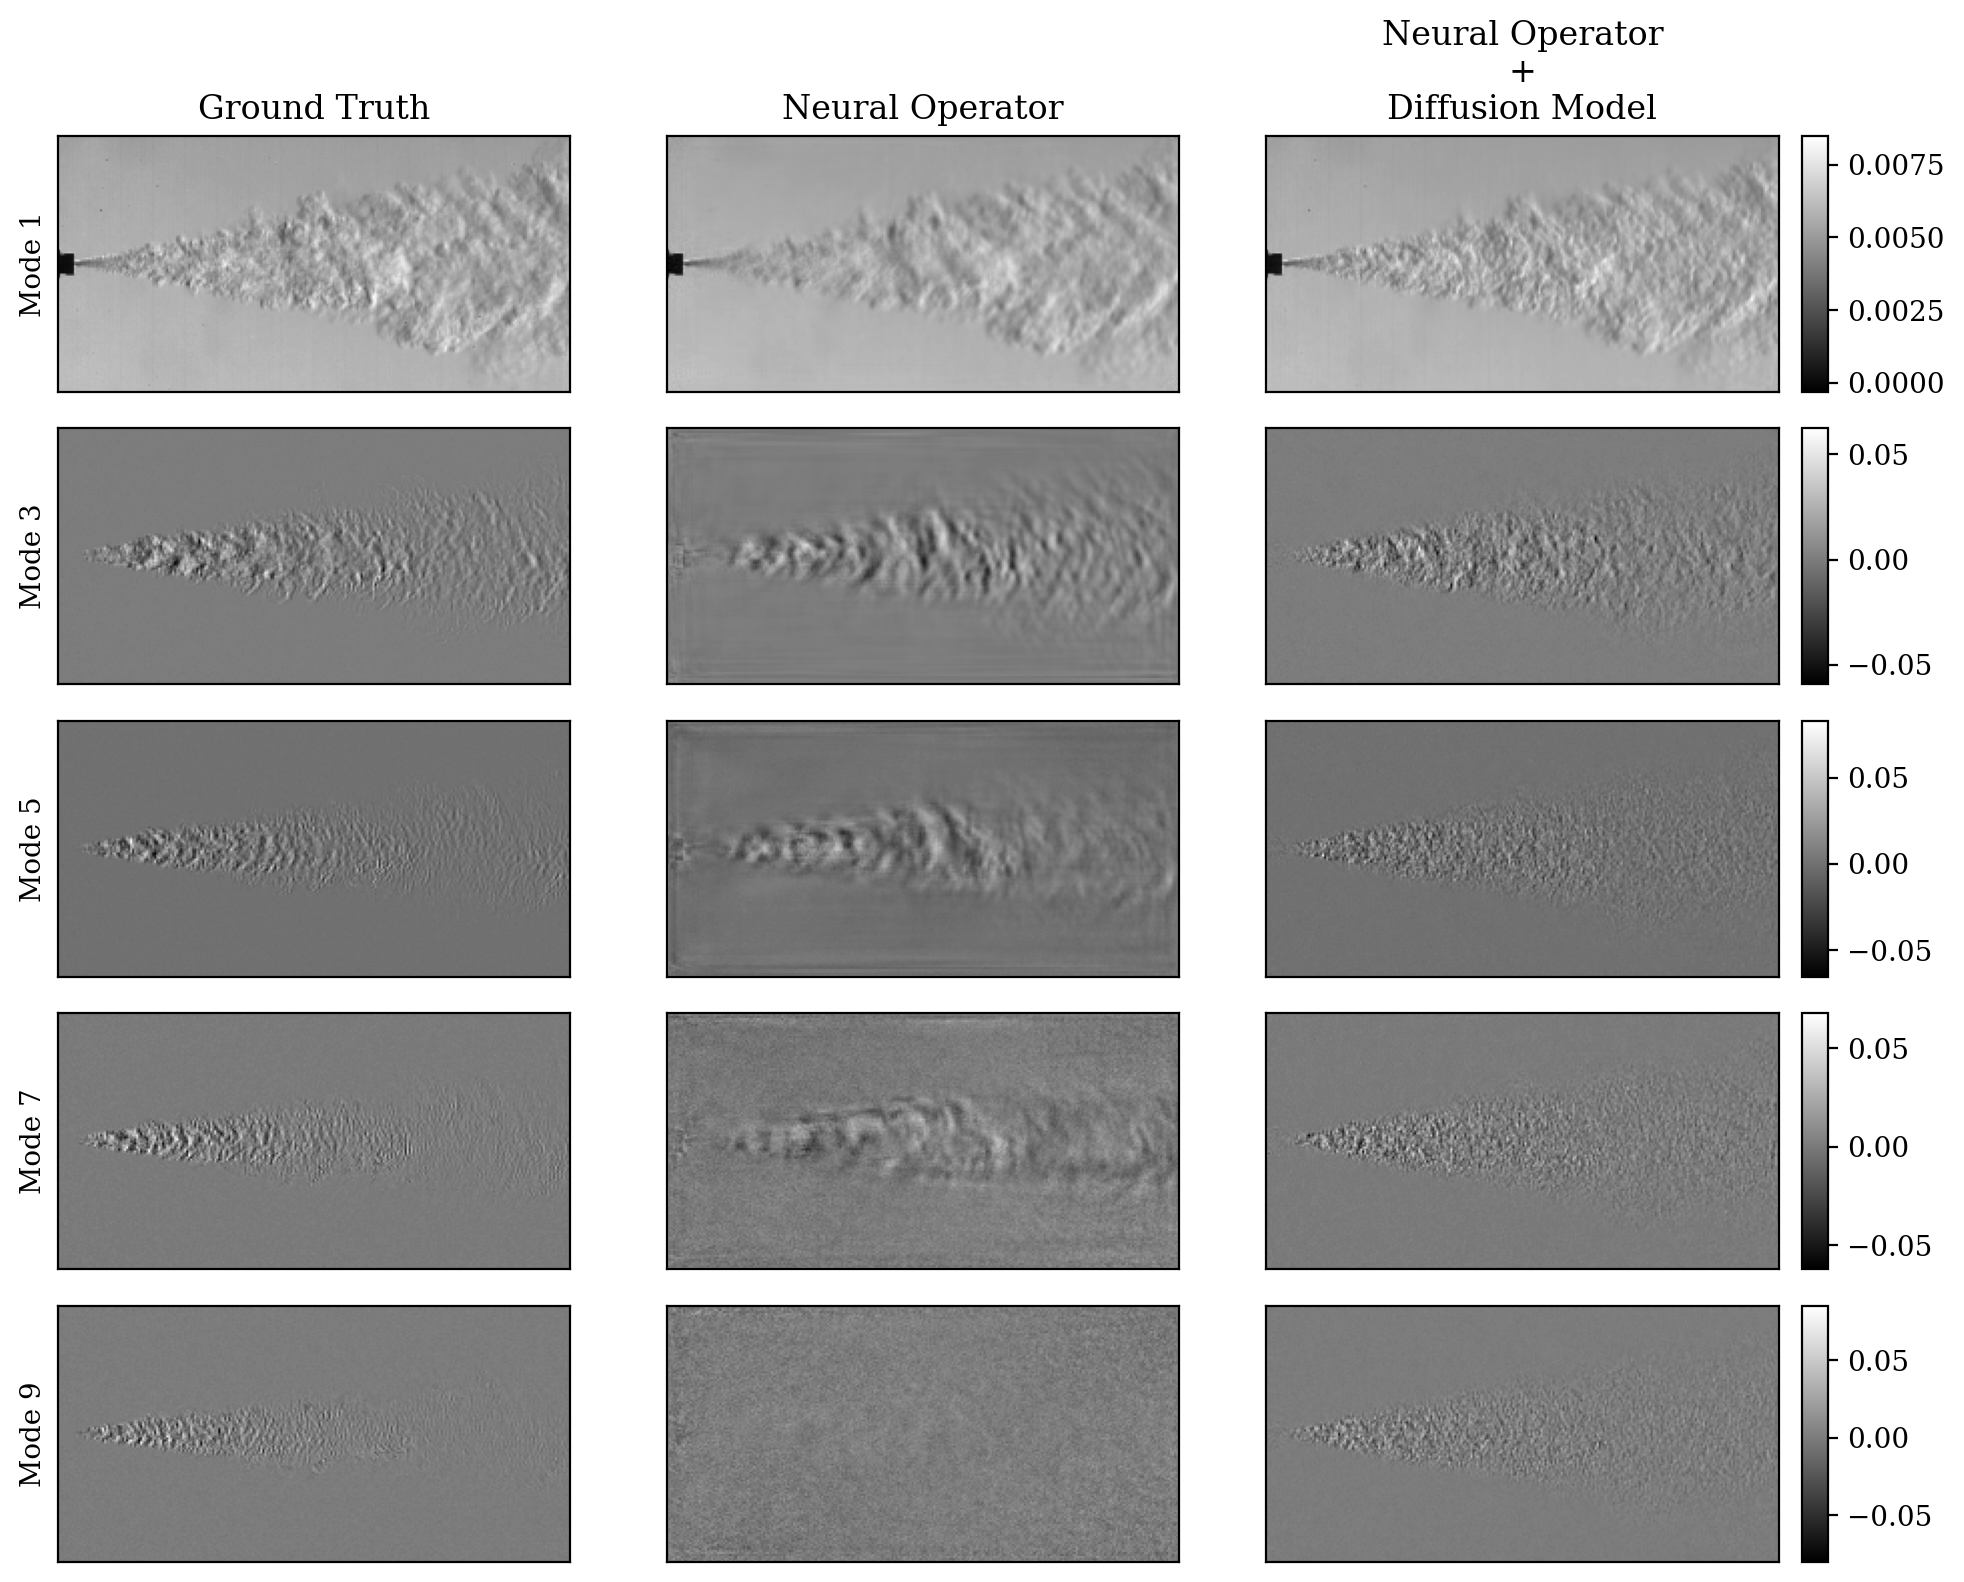

In [32]:
n = V_TRUE.shape[0]
fig, axes = plt.subplots(n, 3, figsize=(10, 8))

for i in range(n):
    # Plot V_TRUE
    vmin_row = min(np.min(V_TRUE[i]), np.min(V_NO[i]), np.min(V_PRED[i]))
    vmax_row = max(np.max(V_TRUE[i]), np.max(V_NO[i]), np.max(V_PRED[i]))
    
    im = axes[i,0].imshow(np.fliplr(V_TRUE[i]), cmap='gray', vmin=vmin_row, vmax=vmax_row)
    # cbar = plt.colorbar(im, ax=axes[i,0], fraction=0.046, pad=0.04, aspect=10)
    # axes[i,0].set_title(f'Mode {mode_idx[i]+1}')
    # axes[i,0].axis('off')
    axes[i,0].set_ylabel(f"Mode {mode_idx[i]+1}")
    axes[i,0].set_xticks([])
    axes[i,0].set_yticks([])

    # Plot V_NO
    im = axes[i,1].imshow(np.fliplr(V_NO[i]), cmap='gray', vmin=vmin_row, vmax=vmax_row)
    # cbar = plt.colorbar(im, ax=axes[i,1], fraction=0.046, pad=0.04, aspect=10)
    # axes[1, i].set_title(f'V_NO {i+1}')
    # axes[i,1].axis('off')
    axes[i,1].set_xticks([])
    axes[i,1].set_yticks([])

    # Plot V_PRED
    im = axes[i,2].imshow(np.fliplr(V_PRED[i]), cmap='gray', vmin=vmin_row, vmax=vmax_row)
    cbar = plt.colorbar(im, ax=axes[i,2], fraction=0.046, pad=0.04, aspect=10)
    # axes[2, i].set_title(f'V_PRED {i+1}')
    # axes[i,2].axis('off')
    axes[i,2].set_xticks([])
    axes[i,2].set_yticks([])

    if i==0:
        axes[i,0].set_title("Ground Truth")
        axes[i,1].set_title("Neural Operator")
        axes[i,2].set_title("Neural Operator\n+\nDiffusion Model")

plt.tight_layout()
plt.show()